In [ ]:
import pandas as pd
from PIL import Image
import torch
import matplotlib.pyplot as plt

In [4]:
PATH = '../logs/train/baseline_parseq/runs/2026-02-09_12-23-13'

train_hnm = pd.read_csv(PATH + '/train_hnm.csv')
val_hnm = pd.read_csv(PATH + '/val_hnm.csv')

full_hnm = pd.concat((train_hnm, val_hnm))

In [10]:
full_hnm['loss_fl'] = (
    full_hnm["loss"]
    .str.replace("tensor(", "", regex=False)
    .str.replace(")", "", regex=False)
    .astype(float)
)

In [12]:
full_hnm_sorted_by_loss = full_hnm.sort_values(by='loss_fl', ascending=False)

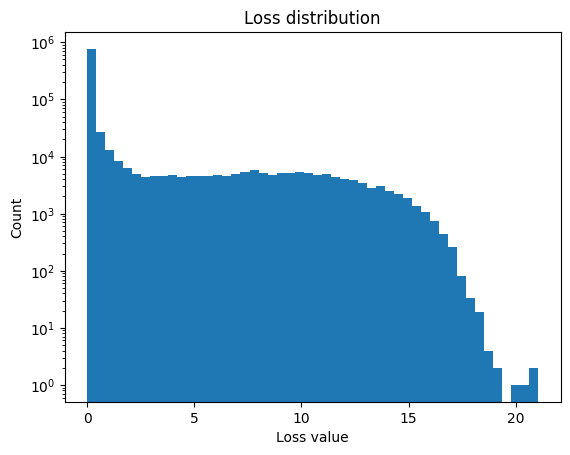

In [ ]:
import matplotlib.pyplot as plt

losses = list(full_hnm.loss_fl)
plt.figure()
plt.hist(losses, bins=50)
plt.xlabel("Loss value")
plt.ylabel("Count")
plt.yscale('log')
plt.title("Loss distribution")
plt.show()


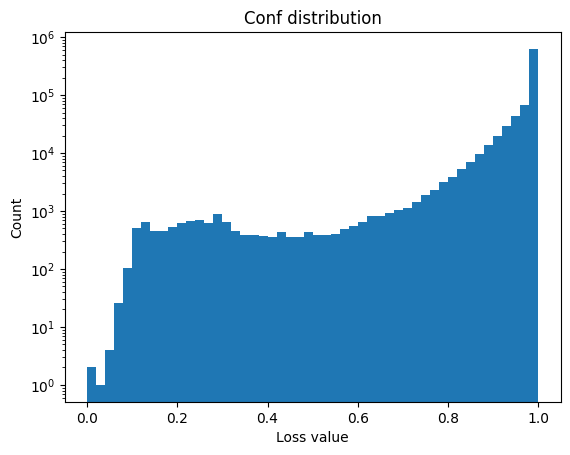

In [57]:
import matplotlib.pyplot as plt

confs = list(full_hnm[full_hnm.loss_fl < 5].confidence)
plt.figure()
plt.hist(confs, bins=50)
plt.xlabel("Loss value")
plt.ylabel("Count")
plt.yscale('log')
plt.title("Conf distribution")
plt.show()

ВЫБИРАЕМ ДАТАСЕТ И ЧЕКАЕМ ЕГО

In [ ]:
full_hnm_bad_10 = full_hnm_sorted_by_loss[full_hnm_sorted_by_loss.loss_fl > 1]
print(len(full_hnm_bad_10))
full_hnm_bad_10 = full_hnm_bad_10[full_hnm_bad_10.path.str.contains('IAT')]

161014


Смотрим примеры данных

gt: графическим, predict: рафическим, loss: 13.9229, confidence: 0.9846129417419434, 
path: D:\ocr-project\modeling_recognizer/../datasets/ocr_dataset\images\DDI/305_285.png


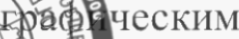

In [361]:
ind = 10

img = Image.open(full_hnm_bad_10.iloc[ind].path)
gt, pred, loss, conf, path = full_hnm_bad_10.iloc[ind]['gt'], full_hnm_bad_10.iloc[ind].pred_text, full_hnm_bad_10.iloc[ind].loss_fl, full_hnm_bad_10.iloc[ind].confidence, full_hnm_bad_10.iloc[ind].path 
print(f'gt: {gt}, predict: {pred}, loss: {loss}, confidence: {conf}, \npath: {path}')
img

УДАЛИМ ЧАСТИ ДАТАСЕТА

In [369]:
files_to_delete = full_hnm_bad_10[full_hnm_bad_10.path.str.contains('IAT')]
paths = list(files_to_delete.path.apply(lambda x: x[47:]))

In [ ]:
dataset_path = '../../datasets/ocr_dataset_v3_31_len.parquet'
dataset = pd.read_parquet(dataset_path)

In [ ]:
dataset_filtered = dataset[~dataset.image_path.isin(paths)]

In [ ]:
dataset_filtered.to_parquet('../../datasets/ocr_dataset_v3_hnm.parquet')